<a href="https://colab.research.google.com/github/john891212-oss/AIFFEL_quest_eng/blob/main/NLP/NLP03/pili96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# project: 챗봇 만들기

구현흐름 : 환경설정=> 데이터 다운로드 => 데이터 정제 => 데이터 토큰화 => 데이터 증강 => 데이터 벡터화 => 모델 훈련 => 성능측정

사용 데이터 : https://github.com/songys/Chatbot_data
챗봇 트레이닝용 문답 페어 11,876개

토큰나이저 : KoNLPy의 mecab =>python mecab  







### gensim 설치 및 환경설정

In [2]:
!pip install gensim
import gensim.downloader as api

wv = api.load('glove-wiki-gigaword-300')

In [3]:
import numpy
import pandas
import torch
import nltk
import gensim

print(numpy.__version__)
print(pandas.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.0.2
2.2.2
2.10.0+cu128
3.9.1
4.4.0


In [4]:
%%capture
!pip install -q konlpy nltk tqdm

In [5]:
!pip install -q mecab-python3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.4/591.4 kB 17.8 MB/s eta 0:00:00


In [6]:
!python3 -m pip install --upgrade pip
!python3 -m pip install konlpy # Python 3.x
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) # MeCab 설치하기

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
Install mecab-ko
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100 1381k  100 1381k    0     0   563k      0  0:00:02  0:00:02 --:--:--  563k
mecab-0.996-ko-0.9.2/
mecab-0.996-ko-0.9.2/example/
mecab-0.996-ko-0.9.2/example/example.cpp
mecab-0.996-ko-0.9.2/example/example_lattice.cpp
mecab-0.996-ko-0.9.2/example/example_lattice.c
mecab-0.996-ko-0.9.2/example/example.c
mecab-0.996-ko-0.9.2/example/thread_test.cpp
mecab-0.996-ko-0.9.2/mecab-config.in
mecab-0.996-ko-0.9.2/man/
mecab-0.996-ko-0.9.2/man/Makefile.am
mecab-0.996-ko-0.9.2/man/mecab.1
mecab-0.996-ko-0.9.2/man/Makefile.in
meca

In [7]:
!pip install -q python-mecab-ko

 과제 조건은 KoNLPy Mecab 사용이지만,
 현재 Colab Python 3.12 환경에서 konlpy.tag.Mecab의 Tagger 오류가 발생했습니다.  
 따라서 동일한 MeCab-ko 기반 형태소 분석기인 python-mecab-ko의 MeCab을 사용했습니다.

In [8]:
from mecab import MeCab

mecab = MeCab()
print(mecab.morphs("오늘 날씨가 정말 좋네요."))

['오늘', '날씨', '가', '정말', '좋', '네요', '.']


데이터 다운로드

In [9]:
import os
import urllib.request
import pandas as pd

DATA_PATH = "ChatbotData.csv"
DATA_URL = "https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

data = pd.read_csv(DATA_PATH)

questions = data["Q"].astype(str).tolist()
answers = data["A"].astype(str).tolist()

print(data.head())
print("questions:", len(questions))
print("answers:", len(answers))

                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
questions: 11823
answers: 11823


데이터 전처리

In [10]:
import re

def preprocess_sentence(sentence):

    # 문자열로 변환 후 앞뒤 공백 제거
    sentence = str(sentence).strip()

    # 영문자 소문자 변환
    sentence = sentence.lower()

    # 영문자, 한글, 숫자, 주요 특수문자 외 제거
    sentence = re.sub(r"[^a-z가-힣0-9?.!,~\s]", " ", sentence)

    # 여러 개의 공백을 하나로 정리
    sentence = re.sub(r"\s+", " ", sentence)

    # 앞뒤 공백 제거
    sentence = sentence.strip()

    return sentence

In [11]:
test_sentences = [
    "Hello!! 오늘 날씨가 좋네요ㅎㅎ",
    "SNS 맞팔 왜 안하지ㅠㅠ??? I'm SO Sad...",
    "ㅋㅋㅋㅋ 진짜??? 대박이다~",
    "I LOVE Python!!! 파이썬 3.12 사용중입니다.",
    "특수문자 @#$%^&* 제거 테스트!"
]

for sentence in test_sentences:
    print("원본:", sentence)
    print("정제:", preprocess_sentence(sentence))
    print()

원본: Hello!! 오늘 날씨가 좋네요ㅎㅎ
정제: hello!! 오늘 날씨가 좋네요

원본: SNS 맞팔 왜 안하지ㅠㅠ??? I'm SO Sad...
정제: sns 맞팔 왜 안하지 ??? i m so sad...

원본: ㅋㅋㅋㅋ 진짜??? 대박이다~
정제: 진짜??? 대박이다~

원본: I LOVE Python!!! 파이썬 3.12 사용중입니다.
정제: i love python!!! 파이썬 3.12 사용중입니다.

원본: 특수문자 @#$%^&* 제거 테스트!
정제: 특수문자 제거 테스트!



In [12]:
prepro_questions = [preprocess_sentence(q) for q in questions]
prepro_answers = [preprocess_sentence(a) for a in answers]

print(prepro_questions[:5])
print(prepro_answers[:5])

['12시 땡!', '1지망 학교 떨어졌어', '3박4일 놀러가고 싶다', '3박4일 정도 놀러가고 싶다', 'ppl 심하네']
['하루가 또 가네요.', '위로해 드립니다.', '여행은 언제나 좋죠.', '여행은 언제나 좋죠.', '눈살이 찌푸려지죠.']


토큰화



In [13]:
def build_corpus(src_data, tgt_data, tokenizer, max_len=40):
    """
    소스 문장 데이터와 타겟 문장 데이터를 정제, 토큰화하여 corpus 생성

    Args:
        src_data: 소스 문장 리스트
        tgt_data: 타겟 문장 리스트
        tokenizer: 토큰화 함수, 예: mecab.morphs
        max_len: 최대 토큰 길이

    Returns:
        src_corpus: 토큰화된 소스 문장 리스트
        tgt_corpus: 토큰화된 타겟 문장 리스트
    """

    src_corpus = []
    tgt_corpus = []

    src_seen = set()
    tgt_seen = set()

    for src_sentence, tgt_sentence in zip(src_data, tgt_data):

        # 1. 전처리
        src_sentence = preprocess_sentence(src_sentence)
        tgt_sentence = preprocess_sentence(tgt_sentence)

        # 2. 토큰화
        src_tokens = tokenizer(src_sentence)
        tgt_tokens = tokenizer(tgt_sentence)

        # 3. 길이 필터링
        if len(src_tokens) >= max_len:
            continue

        if len(tgt_tokens) >= max_len:
            continue

        # 4. 중복 체크를 위해 토큰 리스트를 문자열 또는 tuple로 변환
        src_key = tuple(src_tokens)
        tgt_key = tuple(tgt_tokens)

        # 5. 소스 또는 타겟 중 하나라도 이미 등장했다면 해당 쌍 제외
        if src_key in src_seen:
            continue

        if tgt_key in tgt_seen:
            continue

        # 6. 중복 집합에 추가
        src_seen.add(src_key)
        tgt_seen.add(tgt_key)

        # 7. corpus에 추가
        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus

In [14]:
que_corpus, ans_corpus = build_corpus(
    questions,
    answers,
    mecab.morphs,
    max_len=40
)

In [15]:
print(que_corpus[0])

print(ans_corpus[0])

['12', '시', '땡', '!']
['하루', '가', '또', '가', '네요', '.']


데이터 증강   
1-1 ko.bin 로드   
1-2 Lexical Substitution 함수 구현

In [16]:
!pip install -q gdown

In [17]:
!gdown "https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU" -O ko.zip

Downloading...
From (original): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU
From (redirected): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU&confirm=t&uuid=d244f99f-89ee-4abe-800f-c16b7f7c65f1
To: /content/ko.zip
100% 80.6M/80.6M [00:02<00:00, 37.0MB/s]


In [18]:
!unzip -q ko.zip
!ls -lh

total 208M
-rw-r--r-- 1 root root 869K May 17 14:27 ChatbotData.csv
-rw------- 1 root root  49M Dec 21  2016 ko.bin
-rw------- 1 root root  82M Dec 21  2016 ko.tsv
-rw-r--r-- 1 root root  77M Nov 25  2019 ko.zip
drwxr-xr-x 1 root root 4.0K May 12 13:35 sample_data


In [19]:
import gensim
print(gensim.__version__)

4.4.0


버젼 호환성 문제로 ko.bin 로드 실패

따라서 동일한 Lexical Substitution 과정을 구현하기 위해
현재 que_corpus + ans_corpus를 이용해 Word2Vec을 직접 학습하여 사용

In [20]:
from gensim.models import Word2Vec

word2vec = Word2Vec(
    sentences=que_corpus + ans_corpus,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=1
)

print("현재 corpus 기반 Word2Vec 학습 완료")

현재 corpus 기반 Word2Vec 학습 완료


Lexical Substitution함수 구현

In [21]:
import random

def lexical_sub(sentence, word2vec):
    res = sentence[:]

    if len(res) == 0:
        return res

    stopwords = {
        "<start>", "<end>", "<pad>", "<unk>",
        ".", "?", "!", ",", "~"
    }

    candidate_words = [
        word for word in res
        if word not in stopwords
    ]

    random.shuffle(candidate_words)

    for word in candidate_words:
        try:
            similar_word = word2vec.wv.most_similar(word, topn=1)[0][0]

            return [
                similar_word if token == word else token
                for token in res
            ]

        except KeyError:
            continue

    return res

In [22]:
word2vec.wv.most_similar("사랑", topn=5)

[('기억', 0.9110755920410156),
 ('행복', 0.8989421129226685),
 ('당신', 0.8863211870193481),
 ('시작', 0.8835996389389038),
 ('추억', 0.8829376697540283)]

데이터 증강

In [23]:
aug_que_corpus = [
    lexical_sub(que, word2vec)
    for que in que_corpus
]

aug_ans_corpus = [
    lexical_sub(ans, word2vec)
    for ans in ans_corpus
]

In [24]:
new_que_corpus = []
new_ans_corpus = []

for que, ans, aug_que, aug_ans in zip(
    que_corpus,
    ans_corpus,
    aug_que_corpus,
    aug_ans_corpus
):
    # 원본 질문 - 원본 답변
    new_que_corpus.append(que)
    new_ans_corpus.append(ans)

    # 증강 질문 - 원본 답변
    new_que_corpus.append(aug_que)
    new_ans_corpus.append(ans)

    # 원본 질문 - 증강 답변
    new_que_corpus.append(que)
    new_ans_corpus.append(aug_ans)

assert len(new_que_corpus) == len(new_ans_corpus)
assert len(new_que_corpus) == len(que_corpus) * 3

print("원본 데이터 수:", len(que_corpus))
print("증강 후 데이터 수:", len(new_que_corpus))

원본 데이터 수: 7680
증강 후 데이터 수: 23040


In [25]:
que_corpus = new_que_corpus
ans_corpus = new_ans_corpus

데이터 벡터화

<start><end> 토큰 추가

In [26]:
ans_corpus = [
    ["<start>"] + sentence + ["<end>"]
    for sentence in ans_corpus
]

print(ans_corpus[:3])

[['<start>', '하루', '가', '또', '가', '네요', '.', '<end>'], ['<start>', '하루', '가', '또', '가', '네요', '.', '<end>'], ['<start>', '하루', '가', '결국', '가', '네요', '.', '<end>']]


In [27]:
total_corpus = que_corpus + ans_corpus

print("que_corpus 개수:", len(que_corpus))
print("ans_corpus 개수:", len(ans_corpus))
print("total_corpus 개수:", len(total_corpus))

que_corpus 개수: 23040
ans_corpus 개수: 23040
total_corpus 개수: 46080


vocab 만들기

In [28]:
from collections import Counter

def build_vocab(corpus, vocab_size=12000):
    counter = Counter()

    for sentence in corpus:
        counter.update(sentence)

    special_tokens = ["<pad>", "<unk>", "<start>", "<end>"]

    vocab = special_tokens[:]

    for word, freq in counter.most_common(vocab_size - len(special_tokens)):
        if word not in vocab:
            vocab.append(word)

    word2idx = {word: idx for idx, word in enumerate(vocab)}
    idx2word = {idx: word for word, idx in word2idx.items()}

    return word2idx, idx2word

In [29]:
VOCAB_SIZE = 12000

word2idx, idx2word = build_vocab(total_corpus, VOCAB_SIZE)

print("전체 vocab 크기:", len(word2idx))
print("<pad>:", word2idx["<pad>"])
print("<unk>:", word2idx["<unk>"])
print("<start>:", word2idx["<start>"])
print("<end>:", word2idx["<end>"])

전체 vocab 크기: 6254
<pad>: 0
<unk>: 1
<start>: 2
<end>: 3


토큰을 정수 인덱스로 변환

In [30]:
def tokens_to_ids(tokens, word2idx):
    unk_id = word2idx["<unk>"]
    return [word2idx.get(token, unk_id) for token in tokens]

In [31]:
enc_sequences = [
    tokens_to_ids(sentence, word2idx)
    for sentence in que_corpus
]

dec_sequences = [
    tokens_to_ids(sentence, word2idx)
    for sentence in ans_corpus
]

print(enc_sequences[:2])
print(dec_sequences[:2])

[[2556, 208, 2647, 111], [1313, 208, 2647, 111]]
[[2, 285, 9, 148, 9, 43, 4, 3], [2, 285, 9, 148, 9, 43, 4, 3]]


패딩해서 tensor로 변환

In [32]:
import torch
from torch.nn.utils.rnn import pad_sequence

enc_tensors = [
    torch.tensor(seq, dtype=torch.long)
    for seq in enc_sequences
]

dec_tensors = [
    torch.tensor(seq, dtype=torch.long)
    for seq in dec_sequences
]

enc_train = pad_sequence(
    enc_tensors,
    batch_first=True,
    padding_value=word2idx["<pad>"]
)

dec_train = pad_sequence(
    dec_tensors,
    batch_first=True,
    padding_value=word2idx["<pad>"]
)

print("enc_train shape:", enc_train.shape)
print("dec_train shape:", dec_train.shape)

enc_train shape: torch.Size([23040, 32])
dec_train shape: torch.Size([23040, 39])


In [33]:
print("enc_train[0]:", enc_train[0])
print("dec_train[0]:", dec_train[0])

enc_train[0]: tensor([2556,  208, 2647,  111,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0])
dec_train[0]: tensor([  2, 285,   9, 148,   9,  43,   4,   3,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0])


In [34]:
def ids_to_tokens(ids, idx2word):
    tokens = []

    for idx in ids:
        idx = int(idx)
        token = idx2word[idx]

        if token == "<pad>":
            continue

        tokens.append(token)

    return tokens


print("enc_train[0] 복원:")
print(ids_to_tokens(enc_train[0], idx2word))

print("\ndec_train[0] 복원:")
print(ids_to_tokens(dec_train[0], idx2word))

enc_train[0] 복원:
['12', '시', '땡', '!']

dec_train[0] 복원:
['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']


In [35]:
dec_input = dec_train[:, :-1]
dec_target = dec_train[:, 1:]

print("enc_train shape:", enc_train.shape)
print("dec_train shape:", dec_train.shape)
print("dec_input shape:", dec_input.shape)
print("dec_target shape:", dec_target.shape)

enc_train shape: torch.Size([23040, 32])
dec_train shape: torch.Size([23040, 39])
dec_input shape: torch.Size([23040, 38])
dec_target shape: torch.Size([23040, 38])


In [36]:
print("decoder input:")
print(ids_to_tokens(dec_input[0], idx2word))

print("\ndecoder target:")
print(ids_to_tokens(dec_target[0], idx2word))

decoder input:
['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']

decoder target:
['하루', '가', '또', '가', '네요', '.', '<end>']


In [37]:
def ids_to_tokens(ids, idx2word):
    tokens = []

    for idx in ids:
        idx = int(idx)
        token = idx2word[idx]

        if token == "<pad>":
            continue

        tokens.append(token)

    return tokens


print("Encoder input:")
print(ids_to_tokens(enc_train[0], idx2word))

print("\nDecoder input:")
print(ids_to_tokens(dec_input[0], idx2word))

print("\nDecoder target:")
print(ids_to_tokens(dec_target[0], idx2word))

Encoder input:
['12', '시', '땡', '!']

Decoder input:
['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']

Decoder target:
['하루', '가', '또', '가', '네요', '.', '<end>']


트랜스포머로 훈련  
1-1 데이터셋  
1-2 데이터로더

In [38]:
import torch
from torch.utils.data import Dataset, DataLoader


class ChatbotDataset(Dataset):
    def __init__(self, enc_train, dec_input, dec_target):
        self.enc_train = enc_train
        self.dec_input = dec_input
        self.dec_target = dec_target

    def __len__(self):
        return len(self.enc_train)

    def __getitem__(self, idx):
        return {
            "enc_input": self.enc_train[idx],
            "dec_input": self.dec_input[idx],
            "dec_target": self.dec_target[idx]
        }

In [39]:
BATCH_SIZE = 64

train_dataset = ChatbotDataset(
    enc_train=enc_train,
    dec_input=dec_input,
    dec_target=dec_target
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)

print("dataset size:", len(train_dataset))
print("batch count:", len(train_loader))

dataset size: 23040
batch count: 360


2-1  하이퍼 파라미터 정의  
2-2  트랜스포머

In [40]:
import math
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

VOCAB_SIZE = len(word2idx)

PAD_IDX = word2idx["<pad>"]
UNK_IDX = word2idx["<unk>"]
START_IDX = word2idx["<start>"]
END_IDX = word2idx["<end>"]

# 제출용 하이퍼파라미터
N_LAYERS = 1
D_MODEL = 368
N_HEADS = 8
D_FF = 1024
DROPOUT = 0.2

BATCH_SIZE = 64
EPOCHS = 20
WARMUP_STEPS = 1000

print("VOCAB_SIZE:", VOCAB_SIZE)
print("PAD_IDX:", PAD_IDX)
print("START_IDX:", START_IDX)
print("END_IDX:", END_IDX)

device: cuda
VOCAB_SIZE: 6254
PAD_IDX: 0
START_IDX: 2
END_IDX: 3


In [41]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float()
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)

        # d_model이 홀수일 수도 있으므로 안전 처리
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])

        pe = pe.unsqueeze(0)
        # shape: (1, max_len, d_model)

        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x)

In [42]:
class ChatbotTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        d_model,
        n_heads,
        d_ff,
        n_layers,
        dropout,
        pad_idx
    ):
        super().__init__()

        self.d_model = d_model
        self.pad_idx = pad_idx

        # shared embedding
        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_idx
        )

        self.pos_encoding = PositionalEncoding(
            d_model=d_model,
            dropout=dropout
        )

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=n_heads,
            num_encoder_layers=n_layers,
            num_decoder_layers=n_layers,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True
        )

        self.fc_out = nn.Linear(d_model, vocab_size)

    def make_padding_mask(self, seq):
        """
        seq: (batch, seq_len)
        return: (batch, seq_len)
        True인 위치는 attention에서 무시됨
        """
        return seq == self.pad_idx

    def make_look_ahead_mask(self, size, device):
        """
        Decoder가 미래 토큰을 보지 못하게 하는 causal mask
        return: (size, size)
        """
        mask = torch.triu(
            torch.ones(size, size, device=device),
            diagonal=1
        ).bool()

        return mask

    def forward(self, src, tgt):
        """
        src: 질문 입력, (batch, src_len)
        tgt: decoder input, (batch, tgt_len)
        """

        src_key_padding_mask = self.make_padding_mask(src)
        tgt_key_padding_mask = self.make_padding_mask(tgt)

        tgt_len = tgt.size(1)
        tgt_mask = self.make_look_ahead_mask(tgt_len, tgt.device)

        src_emb = self.embedding(src) * math.sqrt(self.d_model)
        tgt_emb = self.embedding(tgt) * math.sqrt(self.d_model)

        src_emb = self.pos_encoding(src_emb)
        tgt_emb = self.pos_encoding(tgt_emb)

        output = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )

        logits = self.fc_out(output)

        return logits

3-1 Learning Rate Scheduler  
3-2 모델, optimizer, loss 생성

In [43]:
class LearningRateScheduler:
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = max(step, 1)

        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)

        return (self.d_model ** -0.5) * min(arg1, arg2)

In [44]:
model = ChatbotTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    d_ff=D_FF,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = optim.Adam(
    model.parameters(),
    lr=0,
    betas=(0.9, 0.98),
    eps=1e-9
)

lr_scheduler = LearningRateScheduler(
    d_model=D_MODEL,
    warmup_steps=WARMUP_STEPS
)

print(model)

ChatbotTransformer(
  (embedding): Embedding(6254, 368, padding_idx=0)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=368, out_features=368, bias=True)
          )
          (linear1): Linear(in_features=368, out_features=1024, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=1024, out_features=368, bias=True)
          (norm1): LayerNorm((368,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((368,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.2, inplace=False)
          (dropout2): Dropout(p=0.2, inplace=False)
        )
      )
      (norm): LayerNorm((368,), eps=1e-05, elementwise_affine=True)
    )
    (decode

4-1 학습함수  
4-2 훈련실행

In [45]:
def train_one_epoch(model, train_loader, optimizer, criterion, epoch):
    model.train()

    total_loss = 0
    global_step_base = (epoch - 1) * len(train_loader)

    for batch_idx, batch in enumerate(train_loader):
        step = global_step_base + batch_idx + 1

        enc_inputs = batch["enc_input"].to(device)
        dec_inputs = batch["dec_input"].to(device)
        dec_targets = batch["dec_target"].to(device)

        # learning rate update
        lr = lr_scheduler(step)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        optimizer.zero_grad()

        logits = model(enc_inputs, dec_inputs)
        # logits: (batch, dec_seq_len, vocab_size)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            dec_targets.reshape(-1)
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    return avg_loss, lr

In [46]:
loss_history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, current_lr = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        epoch
    )

    loss_history.append(train_loss)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"LR: {current_lr:.8f}"
    )

Epoch 1/20 | Loss: 5.1972 | LR: 0.00059344
Epoch 2/20 | Loss: 3.6925 | LR: 0.00118688
Epoch 3/20 | Loss: 3.3393 | LR: 0.00158622
Epoch 4/20 | Loss: 3.1276 | LR: 0.00137371
Epoch 5/20 | Loss: 2.9508 | LR: 0.00122868
Epoch 6/20 | Loss: 2.8122 | LR: 0.00112163
Epoch 7/20 | Loss: 2.7030 | LR: 0.00103843
Epoch 8/20 | Loss: 2.6112 | LR: 0.00097136
Epoch 9/20 | Loss: 2.5282 | LR: 0.00091581
Epoch 10/20 | Loss: 2.4451 | LR: 0.00086881
Epoch 11/20 | Loss: 2.3776 | LR: 0.00082838
Epoch 12/20 | Loss: 2.3187 | LR: 0.00079311
Epoch 13/20 | Loss: 2.2485 | LR: 0.00076200
Epoch 14/20 | Loss: 2.1953 | LR: 0.00073428
Epoch 15/20 | Loss: 2.1374 | LR: 0.00070938
Epoch 16/20 | Loss: 2.0939 | LR: 0.00068685
Epoch 17/20 | Loss: 2.0504 | LR: 0.00066635
Epoch 18/20 | Loss: 2.0120 | LR: 0.00064757
Epoch 19/20 | Loss: 1.9734 | LR: 0.00063030
Epoch 20/20 | Loss: 1.9408 | LR: 0.00061434


5-1 loss 그래프  
5-2 예문추론

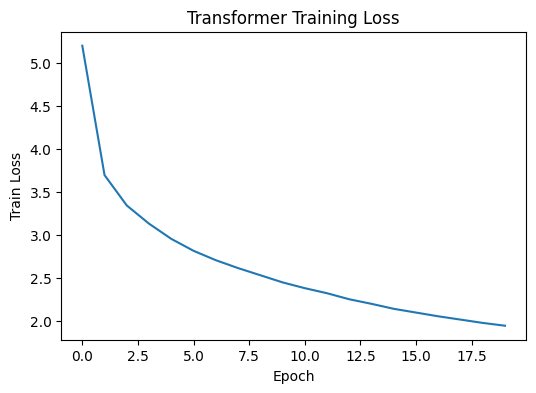

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("Transformer Training Loss")
plt.show()

In [48]:
def sentence_to_tensor(sentence, word2idx, max_len=None):
    sentence = preprocess_sentence(sentence)
    tokens = tokenizer(sentence)

    ids = [
        word2idx.get(token, word2idx["<unk>"])
        for token in tokens
    ]

    if max_len is not None:
        ids = ids[:max_len]

    tensor = torch.tensor(ids, dtype=torch.long).unsqueeze(0)

    return tensor

In [49]:
def translate(sentence, model, word2idx, idx2word, max_len=40):
    model.eval()

    src = sentence_to_tensor(sentence, word2idx).to(device)

    generated = torch.tensor(
        [[START_IDX]],
        dtype=torch.long,
        device=device
    )

    with torch.no_grad():
        for _ in range(max_len):
            logits = model(src, generated)

            next_token_logits = logits[:, -1, :]
            next_token = torch.argmax(next_token_logits, dim=-1).item()

            generated = torch.cat(
                [
                    generated,
                    torch.tensor([[next_token]], device=device)
                ],
                dim=1
            )

            if next_token == END_IDX:
                break

    result_tokens = []

    for idx in generated.squeeze(0).tolist():
        token = idx2word[idx]

        if token == "<start>":
            continue

        result_tokens.append(token)

        if token == "<end>":
            break

    return " ".join(result_tokens)

In [50]:
tokenizer = mecab.morphs

In [51]:
test_sentences = [
    "지루하다, 놀러가고 싶어.",
    "일찍 일어났더니 피곤하다.",
    "간만에 데이트 하기로 했어.",
    "집에 있는다는 소리야."
]

for i, sentence in enumerate(test_sentences, 1):
    output = translate(
        sentence,
        model,
        word2idx,
        idx2word,
        max_len=40
    )

    print(f"{i}. {output}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


1. 저 도 데려가 세요 . <end>
2. 저 도 듣 고 싶 은 걸 잊 어야 해요 . <end>
3. 마음 이 좀 풀렸 길 바랍니다 . <end>
4. 천천히 그만두 세요 . <end>


In [52]:
print("Translations")

for i, sentence in enumerate(test_sentences, 1):
    output = translate(sentence, model, word2idx, idx2word, max_len=40)
    print(f"> {i}. {output}")



Translations
> 1. 저 도 데려가 세요 . <end>
> 2. 저 도 듣 고 싶 은 걸 잊 어야 해요 . <end>
> 3. 마음 이 좀 풀렸 길 바랍니다 . <end>
> 4. 천천히 그만두 세요 . <end>


Bleu 점수

In [53]:
!pip install -q nltk

In [54]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np
import torch

In [55]:
def calculate_bleu(reference, candidate):
    """
    reference: 정답 문장 또는 정답 토큰 리스트
    candidate: 모델이 생성한 문장 또는 생성 토큰 리스트
    """

    # 문자열이면 토큰화
    if isinstance(reference, str):
        reference = preprocess_sentence(reference)
        reference = tokenizer(reference)

    if isinstance(candidate, str):
        candidate = preprocess_sentence(candidate)
        candidate = tokenizer(candidate)

    # 특수 토큰 제거
    remove_tokens = {"<start>", "<end>", "<pad>"}

    reference = [
        token for token in reference
        if token not in remove_tokens
    ]

    candidate = [
        token for token in candidate
        if token not in remove_tokens
    ]

    if len(candidate) == 0:
        return 0.0

    smoothie = SmoothingFunction().method1

    bleu = sentence_bleu(
        [reference],
        candidate,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothie
    )

    return bleu

In [56]:
reference = "잠깐 쉬 어도 돼요 ."
candidate = "잠깐 쉬 어도 돼요 . <end>"

score = calculate_bleu(reference, candidate)

print("BLEU:", score)

BLEU: 0.7598356856515925


In [57]:
def evaluate_bleu(model, que_corpus, ans_corpus, sample_size=100):
    """
    전체 데이터 중 일부 샘플에 대해 BLEU 평균 계산
    """

    model.eval()

    total_bleu = 0.0

    sample_size = min(sample_size, len(que_corpus))

    indices = np.random.choice(
        len(que_corpus),
        size=sample_size,
        replace=False
    )

    for idx in indices:
        question_tokens = que_corpus[idx]
        reference_tokens = ans_corpus[idx]

        question_sentence = " ".join(question_tokens)

        candidate_sentence = translate(
            question_sentence,
            model,
            word2idx,
            idx2word,
            max_len=40
        )

        bleu = calculate_bleu(
            reference_tokens,
            candidate_sentence
        )

        total_bleu += bleu

    avg_bleu = total_bleu / sample_size

    return avg_bleu

In [58]:
avg_bleu = evaluate_bleu(
    model,
    que_corpus,
    ans_corpus,
    sample_size=100
)

print(f"Average BLEU Score: {avg_bleu:.4f}")

Average BLEU Score: 0.0601


BLEU Score는 0.0601로 낮게 측정되었다.    
또한 일부 출력에서 동일 구문이 반복되는 현상이 나타났으며, 이는 greedy decoding, 부족한 학습 epoch, <end> 토큰 학습 부족, 답변 데이터 증강으로 인한 의미 왜곡 등이 원인일 수 있다.   
이를 개선하기 위해 반복 n-gram 방지 decoding, max_len 축소, epoch 증가, 질문 중심 augmentation을 적용할 수 있다.   